In [44]:
import pandas as pd

df1 = pd.read_csv('data_mubawab_grouped.csv')
df2 = pd.read_csv('data_ancfcc_grouped.csv')

In [45]:
df1.rename(columns={'price_m2': 'price_marche_m2'}, inplace=True)
df2.rename(columns={'Valeur en DH/m²': 'price_referentiel_m2'}, inplace=True)


In [46]:
df = pd.merge(df1, df2, on=['property_type', 'arrondissement'])
df

,property_type,arrondissement,price_marche_m2,price_referentiel_m2
0,Appartement,Al Fida,11808.993810,11222.222222
1,Appartement,Aïn Chock,16409.922754,15033.333333
2,Appartement,Aïn Sebaâ,11879.748941,11090.909091
3,Appartement,Ben M'sik,6769.230000,9500.000000
4,Appartement,Hay Hassani,17416.240530,13653.846154
5,Appartement,Hay Mohammadi,30812.330000,9800.000000
6,Appartement,Maârif,17662.922848,18863.636364
7,Appartement,Mers Sultan,13649.277000,14111.111111
8,Appartement,Sidi Moumen,8348.334375,13125.000000
9,Appartement,Sidi Othman,8671.046667,10166.666667


In [ ]:
# valeur aberrante 300kDH/m² !
df=df.drop(df.index[13])

In [ ]:
# Calcul de l'écart des prix et de l'écart en pourcentage
df["ecart"] = df["price_marche_m2"] - df["price_referentiel_m2"]
df["ecart_pct"] = df["ecart"] / df["price_referentiel_m2"]*100

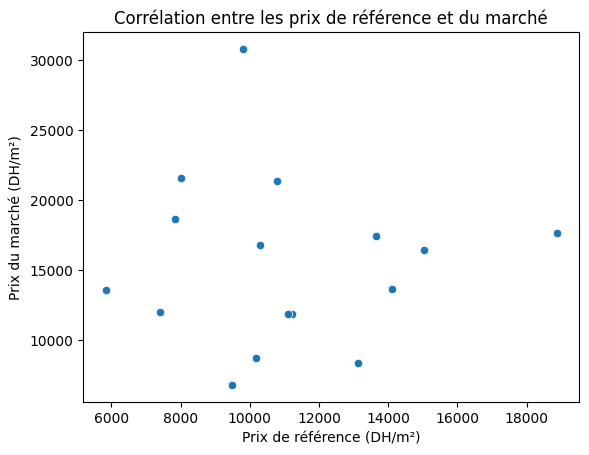

In [ ]:
#  prix référentiel vs prix du marché
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df, x='price_referentiel_m2', y='price_marche_m2')
plt.xlabel('Prix de référence (DH/m²)')
plt.ylabel('Prix du marché (DH/m²)')
plt.title('Corrélation entre les prix de référence et du marché')
plt.show()  

In [ ]:
# Rapprochement des prix de référence et du marché par une régression linéaire
import statsmodels.api as sm
X = df['price_referentiel_m2']
y = df['price_marche_m2']
model = sm.OLS(y, X)
model = model.fit()

In [60]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:        price_marche_m2   R-squared (uncentered):                   0.805
Model:                            OLS   Adj. R-squared (uncentered):              0.792
Method:                 Least Squares   F-statistic:                              62.07
Date:                Wed, 29 Apr 2026   Prob (F-statistic):                    1.04e-06
Time:                        16:12:53   Log-Likelihood:                         -165.02
No. Observations:                  16   AIC:                                      332.0
Df Residuals:                      15   BIC:                                      332.8
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                           coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------